<a href="https://colab.research.google.com/github/ShauryaPrakashVerma/Python_for_AI/blob/main/Pandas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### What is Pandas

Pandas is a fast, powerful, flexible and easy to use open source data analysis and manipulation tool,
built on top of the Python programming language.

https://pandas.pydata.org/about/index.html

# Pandas Series
- in a table each column is a series.
- Its like a column in table. it is a 1D array holding data of any type.

##Importing Pandas

In [ ]:
import pandas as pd

# since pandas is built on top of pandas , it is a good idea to import numpy as well
import numpy as np

### Series from list

In [ ]:
# string
country = ['india','nepal','bhutan','srilanka']
pd.Series(country)

# series always has two things --> index, value of type(object)
# in pandas most of the time string is referred as objects

,0
0,india
1,nepal
2,bhutan
3,srilanka


In [ ]:
# integers
runs = [1,2,3,4,5,7,8,9]
pd.Series(runs)

,0
0,1
1,2
2,3
3,4
4,5
5,7
6,8
7,9


In [ ]:
# custom index
marks = [2,30,23,40]
subjects = ['maths','english','science','hindi']

# we want the subjects as index to the marks
pd.Series(marks, index = subjects)

,0
maths,2
english,30
science,23
hindi,40


In [ ]:
# setting a name

marks = pd.Series(marks, index = subjects, name = "Shaurya's marks")

marks

,Shaurya's marks
maths,2
english,30
science,23
hindi,40


### Creating series from dict

In [ ]:
marks = {
    'maths':67,
    'english': 54,
    'hindi': 19
}

marks_series = pd.Series(marks, name = "Shaurya's marks")
marks_series

# here the keys become the indexes while the values become the actual values

,Shaurya's marks
maths,67
english,54
hindi,19


##Series attributes

In [ ]:
# size
marks_series
marks_series.size

3

In [ ]:
# dtype
marks_series.dtype

dtype('int64')

In [ ]:
# name
marks_series.name

"Shaurya's marks"

In [ ]:
# is_unique
marks_series.is_unique

True

In [ ]:
# index
marks_series.index        # returns an index object

Index(['maths', 'english', 'hindi'], dtype='object')

In [ ]:
# values
marks_series.values

array([67, 54, 19])

## Series using read.csv

In [ ]:
# with one col

# reading data from the file and converting it into series
# data is imported but it is not a series, it is a dataframe
# type(pd.read_csv('/content/subs.csv'))

# to make it a series we have to make a small change


subs = pd.read_csv('/content/subs.csv').squeeze()
print(type(subs))
print(subs)

<class 'pandas.core.series.Series'>
0       48
1       57
2       40
3       43
4       44
      ... 
360    231
361    226
362    155
363    144
364    172
Name: Subscribers gained, Length: 365, dtype: int64


In [ ]:
# runs = pd.read_csv('/content/kohli_ipl.csv').squeeze()
# .squeeze wont work on a data with multiple columns, to make it work we have to specify Index_col as in the following example:

runs = pd.read_csv('/content/kohli_ipl.csv',index_col="match_no").squeeze()
print(type(runs))
print(runs)

<class 'pandas.core.series.Series'>
match_no
1       1
2      23
3      13
4      12
5       1
       ..
211     0
212    20
213    73
214    25
215     7
Name: runs, Length: 215, dtype: int64


In [ ]:
movie = pd.read_csv('/content/bollywood.csv',index_col="movie").squeeze()
print(type(movie))
print(movie)

<class 'pandas.core.series.Series'>
movie
Uri: The Surgical Strike                   Vicky Kaushal
Battalion 609                                Vicky Ahuja
The Accidental Prime Minister (film)         Anupam Kher
Why Cheat India                            Emraan Hashmi
Evening Shadows                         Mona Ambegaonkar
                                              ...       
Hum Tumhare Hain Sanam                    Shah Rukh Khan
Aankhen (2002 film)                     Amitabh Bachchan
Saathiya (film)                             Vivek Oberoi
Company (film)                                Ajay Devgn
Awara Paagal Deewana                        Akshay Kumar
Name: lead, Length: 1500, dtype: object


### Series methods

In [ ]:
# head --> gives top 5 rows by default only for previweing data
print(subs.head())

# we can control the no of rows shown in preview
print(subs.head(3))

0    48
1    57
2    40
3    43
4    44
Name: Subscribers gained, dtype: int64
0    48
1    57
2    40
Name: Subscribers gained, dtype: int64


In [ ]:
# tail --> gives last 5 rows by default only for previewing data
print(subs.tail())

# no of rows can be controlled
print(subs.tail(3))

360    231
361    226
362    155
363    144
364    172
Name: Subscribers gained, dtype: int64
362    155
363    144
364    172
Name: Subscribers gained, dtype: int64


In [ ]:
# sample --> randomly shows 1 row from the dataset

# useful when there is some bias in the dataset

print(movie.sample())


print("\n")
# can control the no of rows in the sample
print(movie.sample(5))

movie
Fanaa (2006 film)    Aamir Khan
Name: lead, dtype: object


movie
Koyelaanchal                     Kannan Arunachalam
Kuku Mathur Ki Jhand Ho Gayi        Siddharth Gupta
Shaadi Se Pehle                      Akshaye Khanna
Guddu Rangeela                         Arshad Warsi
Saankal                         Tanima Bhattacharya
Name: lead, dtype: object


In [ ]:
# value_counts ---> frequency of items in the dataset

# for.eg if we want to find out the no of movies of individual actors
print(movie.value_counts())


# printing for any specific actor
print("\n")
abc = movie.value_counts()
print(abc["Anupam Kher"])

lead
Akshay Kumar         48
Amitabh Bachchan     45
Ajay Devgn           38
Salman Khan          31
Sanjay Dutt          26
                     ..
Seema Azmi            1
Akanksha Puri         1
Charanpreet Insan     1
Jaideep Ahlawat       1
Monali Thakur         1
Name: count, Length: 566, dtype: int64


13


In [ ]:
# sort values --> doesnt change the original dataset, if we want we can change the original dataset

print(runs.sort_values())    # in ascending order
print("\n")
print(runs.sort_values(ascending=False))
print("\n")
print(runs.sort_values(ascending=False).head())
print("\n")
print(runs.sort_values(ascending=False).head(1))
print("\n")
print(runs.sort_values(ascending=False).head(1).values)
print("\n")
print(runs.sort_values(ascending=False).head(1).values[0])    # extracting highest runs of vyrat kohli by method chaining

match_no
8        0
87       0
93       0
91       0
206      0
      ... 
164    100
120    100
123    108
126    109
128    113
Name: runs, Length: 215, dtype: int64


match_no
128    113
126    109
123    108
120    100
164    100
      ... 
93       0
130      0
206      0
207      0
211      0
Name: runs, Length: 215, dtype: int64


match_no
128    113
126    109
123    108
120    100
164    100
Name: runs, dtype: int64


match_no
128    113
Name: runs, dtype: int64


[113]


113


### - try to get into the habit of reassigning variables (e.g., df = df.sort_values()) rather than using inplace=True. It’s much more "Pythonic" and helps avoid these tricky SettingWithCopy warnings and errors!

In [ ]:
# making changes in the original dataset by sort_values function
# changing the value of inplace attribute to True
runs.sort_values(inplace = True)

ValueError: This Series is a view of some other array, to sort in-place you must create a copy

In [ ]:
# sort_index  ---> sorts according to the index
print(movie.sort_index())
print("\n")
print(movie.sort_index(ascending=False))

movie
1920 (film)                   Rajniesh Duggall
1920: London                     Sharman Joshi
1920: The Evil Returns             Vicky Ahuja
1971 (2007 film)                Manoj Bajpayee
2 States (2014 film)              Arjun Kapoor
                                   ...        
Zindagi 50-50                      Veena Malik
Zindagi Na Milegi Dobara        Hrithik Roshan
Zindagi Tere Naam           Mithun Chakraborty
Zokkomon                       Darsheel Safary
Zor Lagaa Ke...Haiya!            Meghan Jadhav
Name: lead, Length: 1500, dtype: object


movie
Zor Lagaa Ke...Haiya!            Meghan Jadhav
Zokkomon                       Darsheel Safary
Zindagi Tere Naam           Mithun Chakraborty
Zindagi Na Milegi Dobara        Hrithik Roshan
Zindagi 50-50                      Veena Malik
                                   ...        
2 States (2014 film)              Arjun Kapoor
1971 (2007 film)                Manoj Bajpayee
1920: The Evil Returns             Vicky Ahuja
1920: 

## Series Maths methods

In [ ]:
# count

# dont confuse with size , size also counts the missing values, count doesn't count the missing values
runs.count()

np.int64(215)

In [ ]:
# sum ---> adds all the items
subs.sum()

# subs.product()   ---> product of all itemms

np.int64(49510)

In [ ]:
# mean
print(subs.mean())

# median
print(runs.median())

# mode
# print the actor who has made most movies
print(movie.mode())  # here 0 is the index , to get rid of it use the next statement
print(movie.mode()[0])

# std --> standard deviation
print(subs.std())

# var --> variance
print(subs.var())

135.64383561643837
24.0
0    Akshay Kumar
Name: lead, dtype: object
Akshay Kumar
62.67502303725269
3928.1585127201556


In [ ]:
# min/ max
print(subs.max())
print(subs.min())

396
33


In [ ]:
# describe --> gives a summary
print(subs.describe())

count    365.000000
mean     135.643836
std       62.675023
min       33.000000
25%       88.000000
50%      123.000000
75%      177.000000
max      396.000000
Name: Subscribers gained, dtype: float64


## Series indexing

In [ ]:
# integer indexing
x = pd.Series([12,13,14,15,16,17,18])
print(x[1])   # positive indexing works, but the negative indexing doesn't work
print(x[-1])

13


KeyError: -1

In [ ]:
movie[1]

/tmp/ipykernel_1470/101055391.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  movie[1]


'Vicky Ahuja'

In [ ]:
movie.iloc[1]   # IN THIS DATSET movie name is the index, but pandas internally maintains an index by default , ehich i have used for accessing the value

'Vicky Ahuja'

In [ ]:
# wierd behaviour flagged
print(movie[-1])

print(movie.iloc[-1])


Akshay Kumar
Akshay Kumar


/tmp/ipykernel_1470/2309222837.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(movie[-1])


### Slicing

In [ ]:
# slicing
print(runs[5:15])

match_no
6      9
7     34
8      0
9     21
10     3
11    10
12    38
13     3
14    11
15    50
Name: runs, dtype: int64


In [ ]:
# negative indexing --> same as python behaviour
print(runs[-5::])

match_no
211     0
212    20
213    73
214    25
215     7
Name: runs, dtype: int64


In [ ]:
# fancy indexing also works here
print(runs[[1,3,6,7]])

match_no
1     1
3    13
6     9
7    34
Name: runs, dtype: int64


In [ ]:
# indexing with labels --> fancy indexing
movie['Zokkomon']

'Darsheel Safary'

## Editing Series

In [ ]:
# using series
marks_series[1] = 100
print(marks_series)

maths       67
english    100
hindi       19
Name: Shaurya's marks, dtype: int64


/tmp/ipykernel_1470/1069262044.py:2: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  marks_series[1] = 100


In [ ]:
# what if the index doesnt exist
marks_series['evs'] = 100

In [ ]:
print(marks_series)

maths       67
english    100
hindi       19
evs        100
Name: Shaurya's marks, dtype: int64


In [ ]:
# slicing
marks_series[0:2] = [100,100]
marks_series

,Shaurya's marks
maths,100
english,100
hindi,19
evs,100


In [ ]:
# fancy indexing
marks_series[[0,1,2]] = [0,0,0]
marks_series

/tmp/ipykernel_1470/623723689.py:2: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  marks_series[[0,1,2]] = [0,0,0]


,Shaurya's marks
maths,0
english,0
hindi,0
evs,100


In [ ]:
# using index label
movie['2 States (2014 film)'] = 'Alia Bhatt'
movie

,lead
movie,
Uri: The Surgical Strike,Vicky Kaushal
Battalion 609,Vicky Ahuja
The Accidental Prime Minister (film),Anupam Kher
Why Cheat India,Emraan Hashmi
Evening Shadows,Mona Ambegaonkar
...,...
Hum Tumhare Hain Sanam,Shah Rukh Khan
Aankhen (2002 film),Amitabh Bachchan
Saathiya (film),Vivek Oberoi


### Series with Python Functionalities

In [ ]:
# len/type/dir/sorted/max/min
print(len(subs))
print(type(subs))
print(dir(subs))
print(sorted(subs))
print(min(subs))
print(max(subs))

365
<class 'pandas.core.series.Series'>
['T', '_AXIS_LEN', '_AXIS_ORDERS', '_AXIS_TO_AXIS_NUMBER', '_HANDLED_TYPES', '__abs__', '__add__', '__and__', '__annotations__', '__array__', '__array_priority__', '__array_ufunc__', '__bool__', '__class__', '__column_consortium_standard__', '__contains__', '__copy__', '__deepcopy__', '__delattr__', '__delitem__', '__dict__', '__dir__', '__divmod__', '__doc__', '__eq__', '__finalize__', '__float__', '__floordiv__', '__format__', '__ge__', '__getattr__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__iadd__', '__iand__', '__ifloordiv__', '__imod__', '__imul__', '__init__', '__init_subclass__', '__int__', '__invert__', '__ior__', '__ipow__', '__isub__', '__iter__', '__itruediv__', '__ixor__', '__le__', '__len__', '__lt__', '__matmul__', '__mod__', '__module__', '__mul__', '__ne__', '__neg__', '__new__', '__nonzero__', '__or__', '__pandas_priority__', '__pos__', '__pow__', '__radd__', '__rand__', '__rdivmod__', '__reduce

In [ ]:
# type conversion
list(marks_series)

[0, 0, 0, 100]

In [ ]:
dict(marks_series)

{'maths': np.int64(0),
 'english': np.int64(0),
 'hindi': np.int64(0),
 'evs': np.int64(100)}

In [ ]:
# membership operator

'2 States (2014 film)' in movie

True

In [ ]:
'Alia Bhatt' in movie.values

True

In [ ]:
# looping
for i in movie.index:
  print(i)

Uri: The Surgical Strike
Battalion 609
The Accidental Prime Minister (film)
Why Cheat India
Evening Shadows
Soni (film)
Fraud Saiyaan
Bombairiya
Manikarnika: The Queen of Jhansi
Thackeray (film)
Amavas
Gully Boy
Hum Chaar
Total Dhamaal
Sonchiriya
Badla (2019 film)
Mard Ko Dard Nahi Hota
Hamid (film)
Photograph (film)
Risknamaa
Mere Pyare Prime Minister
22 Yards
Kesari (film)
Notebook (2019 film)
Junglee (2019 film)
Gone Kesh
Albert Pinto Ko Gussa Kyun Aata Hai?
The Tashkent Files
Kalank
Setters (film)
Student of the Year 2
PM Narendra Modi
De De Pyaar De
India's Most Wanted (film)
Yeh Hai India
Khamoshi (2019 film)
Kabir Singh
Article 15 (film)
One Day: Justice Delivered
Hume Tumse Pyaar Kitna
Super 30 (film)
Family of Thakurganj
Batla House
Jhootha Kahin Ka
Judgementall Hai Kya
Chicken Curry Law
Arjun Patiala
Jabariya Jodi
Pranaam
The Sky Is Pink
Mission Mangal
Saaho
Dream Girl (2019 film)
Section 375
The Zoya Factor (film)
Pal Pal Dil Ke Paas
Prassthanam
P Se Pyaar F Se Faraar
Ghost 

In [ ]:
# Arithmetic Operators(Broadcasting)
100 + marks_series

,Shaurya's marks
maths,100
english,100
hindi,100
evs,200


In [ ]:
# Relational Operators

runs >= 50

,runs
match_no,
1,False
2,False
3,False
4,False
5,False
...,...
211,False
212,False
213,True


In [ ]:
print(runs[runs>50])

match_no
34      58
41      71
44      56
45      67
52      70
57      57
68      73
71      51
73      58
74      65
80      57
81      93
82      99
85      56
97      67
99      73
103     51
104     62
110     82
116     75
117     79
119     80
120    100
122     52
123    108
126    109
127     75
128    113
129     54
131     54
132     62
134     64
137     55
141     58
144     57
145     92
148     68
152     70
160     84
162     67
164    100
175     72
178     90
188     72
197     51
198     53
209     58
213     73
Name: runs, dtype: int64


In [ ]:
# Find no of 50's and 100's scored by kohli
runs[runs >= 50].size

50

In [ ]:
# find number of ducks
runs[runs == 0].size

9

In [ ]:
# find actors who have done more than 20 movies
num_movie = movie.value_counts()
num_movie[num_movie > 20]

,count
lead,
Akshay Kumar,48
Amitabh Bachchan,45
Ajay Devgn,38
Salman Khan,31
Sanjay Dutt,26
Shah Rukh Khan,22
Emraan Hashmi,21


### Plotting Graphs on Series

<Axes: >

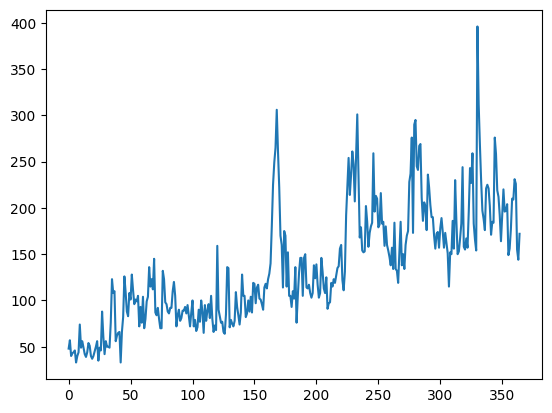

In [ ]:
subs.plot()

<Axes: ylabel='count'>

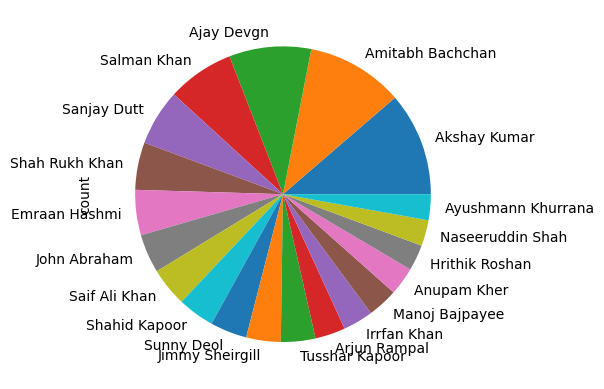

In [ ]:
movie.value_counts().head(20).plot(kind='pie')

### Some Important Series Methods

In [ ]:
# astype
# between
# clip
# drop_duplicates
# isnull
# dropna
# fillna
# isin
# apply
# copy

In [ ]:
# astype
import sys

sys.getsizeof(runs.astype('int16'))

2182

In [ ]:
# between
print(runs[runs.between(51,99)])
print(runs[runs.between(51,99)].size)

match_no
34     58
41     71
44     56
45     67
52     70
57     57
68     73
71     51
73     58
74     65
80     57
81     93
82     99
85     56
97     67
99     73
103    51
104    62
110    82
116    75
117    79
119    80
122    52
127    75
129    54
131    54
132    62
134    64
137    55
141    58
144    57
145    92
148    68
152    70
160    84
162    67
175    72
178    90
188    72
197    51
198    53
209    58
213    73
Name: runs, dtype: int64
43


In [ ]:
# clip
print(subs.clip(100, 200))

0      100
1      100
2      100
3      100
4      100
      ... 
360    200
361    200
362    155
363    144
364    172
Name: Subscribers gained, Length: 365, dtype: int64


In [ ]:
temp = pd.Series([1,2,1,3,4,1,2,3,4,5,6])
print(temp)

0     1
1     2
2     1
3     3
4     4
5     1
6     2
7     3
8     4
9     5
10    6
dtype: int64


In [ ]:
# drop_duplicates
print(temp.drop_duplicates())   # by default keeps the first occurence
print(temp.drop_duplicates(keep="last"))   # keeps the last occurences

0     1
1     2
3     3
4     4
9     5
10    6
dtype: int64
5     1
6     2
7     3
8     4
9     5
10    6
dtype: int64


In [ ]:
print(movie.drop_duplicates())    # keeps only the first movie of each actor

movie
Uri: The Surgical Strike                   Vicky Kaushal
Battalion 609                                Vicky Ahuja
The Accidental Prime Minister (film)         Anupam Kher
Why Cheat India                            Emraan Hashmi
Evening Shadows                         Mona Ambegaonkar
                                              ...       
Sssshhh...                              Tanishaa Mukerji
Rules: Pyaar Ka Superhit Formula                  Tanuja
Right Here Right Now (film)                        Ankit
Talaash: The Hunt Begins...                Rakhee Gulzar
The Pink Mirror                          Edwin Fernandes
Name: lead, Length: 566, dtype: object


In [ ]:
temp[temp.duplicated()]     # tells which values are duplicated
temp.duplicated().sum()

np.int64(5)

In [ ]:
runs.duplicated().sum()

np.int64(137)

In [ ]:
import numpy as np
import pandas as pd


In [ ]:
temp = pd.Series([1,2,3,np.nan,5,6,np.nan,8,np.nan,10])
print(temp)

0     1.0
1     2.0
2     3.0
3     NaN
4     5.0
5     6.0
6     NaN
7     8.0
8     NaN
9    10.0
dtype: float64


In [ ]:
temp.size

10

In [ ]:
temp.count()   # does not count missing values

np.int64(7)

In [ ]:
# isnull
print(temp.isnull())

0    False
1    False
2    False
3     True
4    False
5    False
6     True
7    False
8     True
9    False
dtype: bool


In [ ]:
# how to handle missing values
# - either remove them
# - or fill them

temp.isnull().sum()

np.int64(3)

In [ ]:
# drop(remove) missing values
print(temp.dropna())

0     1.0
1     2.0
2     3.0
4     5.0
5     6.0
7     8.0
9    10.0
dtype: float64


In [ ]:
# fillna()   --> fill the missing values
print(temp.fillna(0))   # --> replace missing values with 0

0     1.0
1     2.0
2     3.0
3     0.0
4     5.0
5     6.0
6     0.0
7     8.0
8     0.0
9    10.0
dtype: float64


In [ ]:
# isin
runs[((runs == 49) | (runs == 99))]
# if we want to check multiple conditions we need not create long checks
# we use isin()

runs[runs.isin([49,99])]

,runs
match_no,
82,99
86,49


In [ ]:
# apply
# if someone says that they want only the first name of the actor in upper case

movie.apply(lambda x:x.split()[0].upper())

,lead
movie,
Uri: The Surgical Strike,VICKY
Battalion 609,VICKY
The Accidental Prime Minister (film),ANUPAM
Why Cheat India,EMRAAN
Evening Shadows,MONA
...,...
Hum Tumhare Hain Sanam,SHAH
Aankhen (2002 film),AMITABH
Saathiya (film),VIVEK


In [ ]:
subs.apply(lambda x:'good day' if x > subs.mean() else 'bad day')

,Subscribers gained
0,bad day
1,bad day
2,bad day
3,bad day
4,bad day
...,...
360,good day
361,good day
362,good day
363,good day


In [ ]:
# copy
new = runs.head()
new

,runs
match_no,
1,1
2,23
3,13
4,12
5,1


In [ ]:
new[1] = 2

In [ ]:
new

,runs
match_no,
1,2
2,23
3,13
4,12
5,1


In [ ]:
runs

,runs
match_no,
1,2
2,23
3,13
4,12
5,1
...,...
211,0
212,20
213,73


In [ ]:
# original data is changed when changed in .head or.tail
# they pass a view of the data
# so any changes are also made in the original data
# to avoid this we make a copy of the original data

In [ ]:
new = runs.head().copy()
new[1] = 100

In [ ]:
print(new)
print(runs)

# on creating a copy of the original data , the copy is modified and the main data is still preserved.

match_no
1    100
2     23
3     13
4     12
5      1
Name: runs, dtype: int64
match_no
1       2
2      23
3      13
4      12
5       1
       ..
211     0
212    20
213    73
214    25
215     7
Name: runs, Length: 215, dtype: int64


# Dataframe
- basically a table of data is a datframe.

### Creating a datframe

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
# using lists
student_data = [
    [100,80,10],
    [90,70,7],
    [120,100,14],
    [80,50,2]
]

pd.DataFrame(student_data, columns=['iq','marks','package'])

,iq,marks,package
0,100,80,10
1,90,70,7
2,120,100,14
3,80,50,2


In [ ]:
# using dictionary

student_dict = {
    'iq':[100,90,120,80],
    'marks': [80,70,100,50],
    'package': [10,7,14,2]
}
students = pd.DataFrame(student_dict)
students

,iq,marks,package
0,100,80,10
1,90,70,7
2,120,100,14
3,80,50,2


In [ ]:
movies = pd.read_csv('movies.csv')
movies

,title_x,imdb_id,poster_path,wiki_link,title_y,original_title,is_adult,year_of_release,runtime,genres,imdb_rating,imdb_votes,story,summary,tagline,actors,wins_nominations,release_date
0,Uri: The Surgical Strike,tt8291224,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Uri:_The_Surgica...,Uri: The Surgical Strike,Uri: The Surgical Strike,0,2019,138,Action|Drama|War,8.4,35112,Divided over five chapters the film chronicle...,Indian army special forces execute a covert op...,NaN,Vicky Kaushal|Paresh Rawal|Mohit Raina|Yami Ga...,4 wins,11 January 2019 (USA)
1,Battalion 609,tt9472208,NaN,https://en.wikipedia.org/wiki/Battalion_609,Battalion 609,Battalion 609,0,2019,131,War,4.1,73,The story revolves around a cricket match betw...,The story of Battalion 609 revolves around a c...,NaN,Vicky Ahuja|Shoaib Ibrahim|Shrikant Kamat|Elen...,NaN,11 January 2019 (India)
2,The Accidental Prime Minister (film),tt6986710,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/The_Accidental_P...,The Accidental Prime Minister,The Accidental Prime Minister,0,2019,112,Biography|Drama,6.1,5549,Based on the memoir by Indian policy analyst S...,Explores Manmohan Singh's tenure as the Prime ...,NaN,Anupam Kher|Akshaye Khanna|Aahana Kumra|Atul S...,NaN,11 January 2019 (USA)
3,Why Cheat India,tt8108208,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Why_Cheat_India,Why Cheat India,Why Cheat India,0,2019,121,Crime|Drama,6.0,1891,The movie focuses on existing malpractices in ...,The movie focuses on existing malpractices in ...,NaN,Emraan Hashmi|Shreya Dhanwanthary|Snighdadeep ...,NaN,18 January 2019 (USA)
4,Evening Shadows,tt6028796,NaN,https://en.wikipedia.org/wiki/Evening_Shadows,Evening Shadows,Evening Shadows,0,2018,102,Drama,7.3,280,While gay rights and marriage equality has bee...,Under the 'Evening Shadows' truth often plays...,NaN,Mona Ambegaonkar|Ananth Narayan Mahadevan|Deva...,17 wins & 1 nomination,11 January 2019 (India)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1624,Tera Mera Saath Rahen,tt0301250,https://upload.wikimedia.org/wikipedia/en/2/2b...,https://en.wikipedia.org/wiki/Tera_Mera_Saath_...,Tera Mera Saath Rahen,Tera Mera Saath Rahen,0,2001,148,Drama,4.9,278,Raj Dixit lives with his younger brother Rahu...,A man is torn between his handicapped brother ...,NaN,Ajay Devgn|Sonali Bendre|Namrata Shirodkar|Pre...,NaN,7 November 2001 (India)
1625,Yeh Zindagi Ka Safar,tt0298607,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Yeh_Zindagi_Ka_S...,Yeh Zindagi Ka Safar,Yeh Zindagi Ka Safar,0,2001,146,Drama,3.0,133,Hindi pop-star Sarina Devan lives a wealthy ...,A singer finds out she was adopted when the ed...,NaN,Ameesha Patel|Jimmy Sheirgill|Nafisa Ali|Gulsh...,NaN,16 November 2001 (India)
1626,Sabse Bada Sukh,tt0069204,NaN,https://en.wikipedia.org/wiki/Sabse_Bada_Sukh,Sabse Bada Sukh,Sabse Bada Sukh,0,2018,\N,Comedy|Drama,6.1,13,Village born Lalloo re-locates to Bombay and ...,Village born Lalloo re-locates to Bombay and ...,NaN,Vijay Arora|Asrani|Rajni Bala|Kumud Damle|Utpa...,NaN,NaN
1627,Daaka,tt10833860,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Daaka,Daaka,Daaka,0,2019,136,Action,7.4,38,Shinda tries robbing a bank so he can be wealt...,Shinda tries robbing a bank so he can be wealt...,NaN,Gippy Grewal|Zareen Khan|,NaN,1 November 2019 (USA)


In [ ]:
ipl = pd.read_csv('ipl-matches.csv')
ipl

,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,SuperOver,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
0,1312200,Ahmedabad,2022-05-29,2022,Final,Rajasthan Royals,Gujarat Titans,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,bat,N,Gujarat Titans,Wickets,7.0,NaN,HH Pandya,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",CB Gaffaney,Nitin Menon
1,1312199,Ahmedabad,2022-05-27,2022,Qualifier 2,Royal Challengers Bangalore,Rajasthan Royals,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,field,N,Rajasthan Royals,Wickets,7.0,NaN,JC Buttler,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...",CB Gaffaney,Nitin Menon
2,1312198,Kolkata,2022-05-25,2022,Eliminator,Royal Challengers Bangalore,Lucknow Super Giants,"Eden Gardens, Kolkata",Lucknow Super Giants,field,N,Royal Challengers Bangalore,Runs,14.0,NaN,RM Patidar,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['Q de Kock', 'KL Rahul', 'M Vohra', 'DJ Hooda...",J Madanagopal,MA Gough
3,1312197,Kolkata,2022-05-24,2022,Qualifier 1,Rajasthan Royals,Gujarat Titans,"Eden Gardens, Kolkata",Gujarat Titans,field,N,Gujarat Titans,Wickets,7.0,NaN,DA Miller,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",BNJ Oxenford,VK Sharma
4,1304116,Mumbai,2022-05-22,2022,70,Sunrisers Hyderabad,Punjab Kings,"Wankhede Stadium, Mumbai",Sunrisers Hyderabad,bat,N,Punjab Kings,Wickets,5.0,NaN,Harpreet Brar,"['PK Garg', 'Abhishek Sharma', 'RA Tripathi', ...","['JM Bairstow', 'S Dhawan', 'M Shahrukh Khan',...",AK Chaudhary,NA Patwardhan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
945,335986,Kolkata,2008-04-20,2007/08,4,Kolkata Knight Riders,Deccan Chargers,Eden Gardens,Deccan Chargers,bat,N,Kolkata Knight Riders,Wickets,5.0,NaN,DJ Hussey,"['WP Saha', 'BB McCullum', 'RT Ponting', 'SC G...","['AC Gilchrist', 'Y Venugopal Rao', 'VVS Laxma...",BF Bowden,K Hariharan
946,335985,Mumbai,2008-04-20,2007/08,5,Mumbai Indians,Royal Challengers Bangalore,Wankhede Stadium,Mumbai Indians,bat,N,Royal Challengers Bangalore,Wickets,5.0,NaN,MV Boucher,"['L Ronchi', 'ST Jayasuriya', 'DJ Thornely', '...","['S Chanderpaul', 'R Dravid', 'LRPL Taylor', '...",SJ Davis,DJ Harper
947,335984,Delhi,2008-04-19,2007/08,3,Delhi Daredevils,Rajasthan Royals,Feroz Shah Kotla,Rajasthan Royals,bat,N,Delhi Daredevils,Wickets,9.0,NaN,MF Maharoof,"['G Gambhir', 'V Sehwag', 'S Dhawan', 'MK Tiwa...","['T Kohli', 'YK Pathan', 'SR Watson', 'M Kaif'...",Aleem Dar,GA Pratapkumar
948,335983,Chandigarh,2008-04-19,2007/08,2,Kings XI Punjab,Chennai Super Kings,"Punjab Cricket Association Stadium, Mohali",Chennai Super Kings,bat,N,Chennai Super Kings,Runs,33.0,NaN,MEK Hussey,"['K Goel', 'JR Hopes', 'KC Sangakkara', 'Yuvra...","['PA Patel', 'ML Hayden', 'MEK Hussey', 'MS Dh...",MR Benson,SL Shastri


### DataFrame Attributes and Methods

In [ ]:
# shape
movies.shape

(1629, 18)

In [ ]:
ipl.shape

(950, 20)

In [ ]:
# dtypes
movies.dtypes
# return is a series where index is the column name and the datatype is the value.
# in pandas lingo object refers to a string

,0
title_x,object
imdb_id,object
poster_path,object
wiki_link,object
title_y,object
original_title,object
is_adult,int64
year_of_release,int64
runtime,object
genres,object


In [ ]:
# index
movies.index

RangeIndex(start=0, stop=1629, step=1)

In [ ]:
# columns
movies.columns

Index(['title_x', 'imdb_id', 'poster_path', 'wiki_link', 'title_y',
       'original_title', 'is_adult', 'year_of_release', 'runtime', 'genres',
       'imdb_rating', 'imdb_votes', 'story', 'summary', 'tagline', 'actors',
       'wins_nominations', 'release_date'],
      dtype='object')

In [ ]:
ipl.columns

Index(['ID', 'City', 'Date', 'Season', 'MatchNumber', 'Team1', 'Team2',
       'Venue', 'TossWinner', 'TossDecision', 'SuperOver', 'WinningTeam',
       'WonBy', 'Margin', 'method', 'Player_of_Match', 'Team1Players',
       'Team2Players', 'Umpire1', 'Umpire2'],
      dtype='object')

In [ ]:
# values

ipl.values
# returns 2D numpy array

array([[1312200, 'Ahmedabad', '2022-05-29', ...,
        "['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pandya', 'DA Miller', 'R Tewatia', 'Rashid Khan', 'R Sai Kishore', 'LH Ferguson', 'Yash Dayal', 'Mohammed Shami']",
        'CB Gaffaney', 'Nitin Menon'],
       [1312199, 'Ahmedabad', '2022-05-27', ...,
        "['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D Padikkal', 'SO Hetmyer', 'R Parag', 'R Ashwin', 'TA Boult', 'YS Chahal', 'M Prasidh Krishna', 'OC McCoy']",
        'CB Gaffaney', 'Nitin Menon'],
       [1312198, 'Kolkata', '2022-05-25', ...,
        "['Q de Kock', 'KL Rahul', 'M Vohra', 'DJ Hooda', 'MP Stoinis', 'E Lewis', 'KH Pandya', 'PVD Chameera', 'Mohsin Khan', 'Avesh Khan', 'Ravi Bishnoi']",
        'J Madanagopal', 'MA Gough'],
       ...,
       [335984, 'Delhi', '2008-04-19', ...,
        "['T Kohli', 'YK Pathan', 'SR Watson', 'M Kaif', 'DS Lehmann', 'RA Jadeja', 'M Rawat', 'D Salunkhe', 'SK Warne', 'SK Trivedi', 'MM Patel']",
        'Aleem Dar', 'GA Pratapkumar'],
    

In [ ]:
# head and tail
movies.head()

,title_x,imdb_id,poster_path,wiki_link,title_y,original_title,is_adult,year_of_release,runtime,genres,imdb_rating,imdb_votes,story,summary,tagline,actors,wins_nominations,release_date
0,Uri: The Surgical Strike,tt8291224,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Uri:_The_Surgica...,Uri: The Surgical Strike,Uri: The Surgical Strike,0,2019,138,Action|Drama|War,8.4,35112,Divided over five chapters the film chronicle...,Indian army special forces execute a covert op...,NaN,Vicky Kaushal|Paresh Rawal|Mohit Raina|Yami Ga...,4 wins,11 January 2019 (USA)
1,Battalion 609,tt9472208,NaN,https://en.wikipedia.org/wiki/Battalion_609,Battalion 609,Battalion 609,0,2019,131,War,4.1,73,The story revolves around a cricket match betw...,The story of Battalion 609 revolves around a c...,NaN,Vicky Ahuja|Shoaib Ibrahim|Shrikant Kamat|Elen...,NaN,11 January 2019 (India)
2,The Accidental Prime Minister (film),tt6986710,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/The_Accidental_P...,The Accidental Prime Minister,The Accidental Prime Minister,0,2019,112,Biography|Drama,6.1,5549,Based on the memoir by Indian policy analyst S...,Explores Manmohan Singh's tenure as the Prime ...,NaN,Anupam Kher|Akshaye Khanna|Aahana Kumra|Atul S...,NaN,11 January 2019 (USA)
3,Why Cheat India,tt8108208,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Why_Cheat_India,Why Cheat India,Why Cheat India,0,2019,121,Crime|Drama,6.0,1891,The movie focuses on existing malpractices in ...,The movie focuses on existing malpractices in ...,NaN,Emraan Hashmi|Shreya Dhanwanthary|Snighdadeep ...,NaN,18 January 2019 (USA)
4,Evening Shadows,tt6028796,NaN,https://en.wikipedia.org/wiki/Evening_Shadows,Evening Shadows,Evening Shadows,0,2018,102,Drama,7.3,280,While gay rights and marriage equality has bee...,Under the 'Evening Shadows' truth often plays...,NaN,Mona Ambegaonkar|Ananth Narayan Mahadevan|Deva...,17 wins & 1 nomination,11 January 2019 (India)


In [ ]:
# tail
ipl.tail

<bound method NDFrame.tail of           ID        City        Date   Season  MatchNumber  \
0    1312200   Ahmedabad  2022-05-29     2022        Final   
1    1312199   Ahmedabad  2022-05-27     2022  Qualifier 2   
2    1312198     Kolkata  2022-05-25     2022   Eliminator   
3    1312197     Kolkata  2022-05-24     2022  Qualifier 1   
4    1304116      Mumbai  2022-05-22     2022           70   
..       ...         ...         ...      ...          ...   
945   335986     Kolkata  2008-04-20  2007/08            4   
946   335985      Mumbai  2008-04-20  2007/08            5   
947   335984       Delhi  2008-04-19  2007/08            3   
948   335983  Chandigarh  2008-04-19  2007/08            2   
949   335982   Bangalore  2008-04-18  2007/08            1   

                           Team1                        Team2  \
0               Rajasthan Royals               Gujarat Titans   
1    Royal Challengers Bangalore             Rajasthan Royals   
2    Royal Challengers Bangalore         Lucknow Super Giants   
3               Rajasthan Royals               Gujarat Titans   
4            Sunrisers Hyderabad                 Punjab Kings   
..                           ...                          ...   
945        Kolkata Knight Riders              Deccan Chargers   
946               Mumbai Indians  Royal Challengers Bangalore   
947             Delhi Daredevils             Rajasthan Royals   
948              Kings XI Punjab          Chennai Super Kings   
949  Royal Challengers Bangalore        Kolkata Knight Riders   

                                          Venue                   TossWinner  \
0              Narendra Modi Stadium, Ahmedabad             Rajasthan Royals   
1              Narendra Modi Stadium, Ahmedabad             Rajasthan Royals   
2                         Eden Gardens, Kolkata         Lucknow Super Giants   
3                         Eden Gardens, Kolkata               Gujarat Titans   
4                      Wankhede Stadium, Mumbai          Sunrisers Hyderabad   
..                                          ...                          ...   
945                                Eden Gardens              Deccan Chargers   
946                            Wankhede Stadium               Mumbai Indians   
947                            Feroz Shah Kotla             Rajasthan Royals   
948  Punjab Cricket Association Stadium, Mohali          Chennai Super Kings   
949                       M Chinnaswamy Stadium  Royal Challengers Bangalore   

    TossDecision SuperOver                  WinningTeam    WonBy  Margin  \
0            bat         N               Gujarat Titans  Wickets     7.0   
1          field         N             Rajasthan Royals  Wickets     7.0   
2          field         N  Royal Challengers Bangalore     Runs    14.0   
3          field         N               Gujarat Titans  Wickets     7.0   
4            bat         N                 Punjab Kings  Wickets     5.0   
..           ...       ...                          ...      ...     ...   
945          bat         N        Kolkata Knight Riders  Wickets     5.0   
946          bat         N  Royal Challengers Bangalore  Wickets     5.0   
947          bat         N             Delhi Daredevils  Wickets     9.0   
948          bat         N          Chennai Super Kings     Runs    33.0   
949        field         N        Kolkata Knight Riders     Runs   140.0   

    method Player_of_Match                                       Team1Players  \
0      NaN       HH Pandya  ['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...   
1      NaN      JC Buttler  ['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...   
2      NaN      RM Patidar  ['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...   
3      NaN       DA Miller  ['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...   
4      NaN   Harpreet Brar  ['PK Garg', 'Abhishek Sharma', 'RA Tripathi', ...   
..     ...             ...                                                ...   
945

In [ ]:
# sample
ipl.sample(5)

,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,SuperOver,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
885,392188,Cape Town,2009-04-22,2009,8,Royal Challengers Bangalore,Deccan Chargers,Newlands,Deccan Chargers,bat,N,Deccan Chargers,Runs,24.0,NaN,AC Gilchrist,"['JD Ryder', 'RV Uthappa', 'JH Kallis', 'KP Pi...","['AC Gilchrist', 'HH Gibbs', 'VVS Laxman', 'RG...",M Erasmus,AM Saheba
2,1312198,Kolkata,2022-05-25,2022,Eliminator,Royal Challengers Bangalore,Lucknow Super Giants,"Eden Gardens, Kolkata",Lucknow Super Giants,field,N,Royal Challengers Bangalore,Runs,14.0,NaN,RM Patidar,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['Q de Kock', 'KL Rahul', 'M Vohra', 'DJ Hooda...",J Madanagopal,MA Gough
222,1178407,Chandigarh,2019-04-16,2019,32,Kings XI Punjab,Rajasthan Royals,Punjab Cricket Association IS Bindra Stadium,Rajasthan Royals,field,N,Kings XI Punjab,Runs,12.0,NaN,R Ashwin,"['KL Rahul', 'CH Gayle', 'MA Agarwal', 'DA Mil...","['RA Tripathi', 'JC Buttler', 'SV Samson', 'AM...",AK Chaudhary,VA Kulkarni
937,335994,Mumbai,2008-04-27,2007/08,14,Mumbai Indians,Deccan Chargers,Dr DY Patil Sports Academy,Deccan Chargers,field,N,Deccan Chargers,Wickets,10.0,NaN,AC Gilchrist,"['L Ronchi', 'ST Jayasuriya', 'AM Rahane', 'RV...","['AC Gilchrist', 'VVS Laxman', 'A Symonds', 'R...",Asad Rauf,SL Shastri
673,548334,Mumbai,2012-04-22,2012,28,Mumbai Indians,Kings XI Punjab,Wankhede Stadium,Mumbai Indians,bat,N,Kings XI Punjab,Wickets,6.0,NaN,SE Marsh,"['JEC Franklin', 'SR Tendulkar', 'RG Sharma', ...","['N Saini', 'Mandeep Singh', 'SE Marsh', 'DJ H...",S Ravi,RJ Tucker


In [ ]:
# info
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1629 entries, 0 to 1628
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   title_x           1629 non-null   object 
 1   imdb_id           1629 non-null   object 
 2   poster_path       1526 non-null   object 
 3   wiki_link         1629 non-null   object 
 4   title_y           1629 non-null   object 
 5   original_title    1629 non-null   object 
 6   is_adult          1629 non-null   int64  
 7   year_of_release   1629 non-null   int64  
 8   runtime           1629 non-null   object 
 9   genres            1629 non-null   object 
 10  imdb_rating       1629 non-null   float64
 11  imdb_votes        1629 non-null   int64  
 12  story             1609 non-null   object 
 13  summary           1629 non-null   object 
 14  tagline           557 non-null    object 
 15  actors            1624 non-null   object 
 16  wins_nominations  707 non-null    object 


In [ ]:
# describe    --> gives a summary of the data
movies.describe()

,is_adult,year_of_release,imdb_rating,imdb_votes
count,1629.0,1629.000000,1629.000000,1629.000000
mean,0.0,2010.263966,5.557459,5384.263352
std,0.0,5.381542,1.567609,14552.103231
min,0.0,2001.000000,0.000000,0.000000
25%,0.0,2005.000000,4.400000,233.000000
50%,0.0,2011.000000,5.600000,1000.000000
75%,0.0,2015.000000,6.800000,4287.000000
max,0.0,2019.000000,9.400000,310481.000000


In [ ]:
# isnull  --> in data frmae it checks for null values
movies.isnull().sum()

,0
title_x,0
imdb_id,0
poster_path,103
wiki_link,0
title_y,0
original_title,0
is_adult,0
year_of_release,0
runtime,0
genres,0


In [ ]:
# duplicated
ipl.duplicated().sum()

np.int64(0)

In [ ]:
# reaname --> renames the column name in the dataframe
students.rename(columns={'marks':'percent', 'ppackage':'lpa'})   # not permanent changes
students.rename(columns={'marks':'percent', 'ppackage':'lpa'},inplace = True)  # permanent changes (ie in the original data)

### Math Methods

In [ ]:
# sum


# columwise and rowise applies to all maths methods
students.sum()     #columnwise sum
students.sum(axis=1)    #rowise sum

,0
0,190
1,167
2,234
3,132


In [ ]:
students.mean()   # column wise
students.mean(axis=1)  # rowise

,0
0,63.333333
1,55.666667
2,78.000000
3,44.000000


In [ ]:
students.min()    # columnwise

,0
iq,80
percent,50
package,2


In [ ]:
students.max()

,0
iq,120
percent,100
package,14


In [ ]:
# variance
students.var()

,0
iq,291.666667
percent,433.333333
package,25.583333


In [ ]:
# standard deviation
students.std()

,0
iq,17.078251
percent,20.816660
package,5.057997


## Selecting a column from the dataframe

In [ ]:
# single cols
movies['actors']

# table is a dataframe while the column is a series
# here it is proved
print(type(movies['actors']))

<class 'pandas.core.series.Series'>


In [ ]:
# multiple columns

movies[['title_x','imdb_id','title_y']]    # now this is a dataframe, ordeer in the list matters for order in the dataframe

,title_x,imdb_id,title_y
0,Uri: The Surgical Strike,tt8291224,Uri: The Surgical Strike
1,Battalion 609,tt9472208,Battalion 609
2,The Accidental Prime Minister (film),tt6986710,The Accidental Prime Minister
3,Why Cheat India,tt8108208,Why Cheat India
4,Evening Shadows,tt6028796,Evening Shadows
...,...,...,...
1624,Tera Mera Saath Rahen,tt0301250,Tera Mera Saath Rahen
1625,Yeh Zindagi Ka Safar,tt0298607,Yeh Zindagi Ka Safar
1626,Sabse Bada Sukh,tt0069204,Sabse Bada Sukh
1627,Daaka,tt10833860,Daaka


### Selecting rows from a DataFrame

- **iloc** - searches using index positions
- **loc** - searches using index labels

In [ ]:
student_dict = {
    'name':['nitish','ankit','rupesh','rishabh','amit','ankita'],
    'iq':[100,90,120,80,0,0],
    'marks':[80,70,100,50,0,0],
    'package':[10,7,14,2,0,0]
}
students = pd.DataFrame(student_dict)
students.set_index('name',inplace=True)
students

,iq,marks,package
name,,,
nitish,100,80,10
ankit,90,70,7
rupesh,120,100,14
rishabh,80,50,2
amit,0,0,0
ankita,0,0,0


In [ ]:
movies.iloc[0]    # returns a series since a single row is being fetched

,0
title_x,Uri: The Surgical Strike
imdb_id,tt8291224
poster_path,https://upload.wikimedia.org/wikipedia/en/thum...
wiki_link,https://en.wikipedia.org/wiki/Uri:_The_Surgica...
title_y,Uri: The Surgical Strike
original_title,Uri: The Surgical Strike
is_adult,0
year_of_release,2019
runtime,138
genres,Action|Drama|War


In [ ]:
# multiple rows
movies.iloc[0:5]    # return a database

,title_x,imdb_id,poster_path,wiki_link,title_y,original_title,is_adult,year_of_release,runtime,genres,imdb_rating,imdb_votes,story,summary,tagline,actors,wins_nominations,release_date
0,Uri: The Surgical Strike,tt8291224,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Uri:_The_Surgica...,Uri: The Surgical Strike,Uri: The Surgical Strike,0,2019,138,Action|Drama|War,8.4,35112,Divided over five chapters the film chronicle...,Indian army special forces execute a covert op...,NaN,Vicky Kaushal|Paresh Rawal|Mohit Raina|Yami Ga...,4 wins,11 January 2019 (USA)
1,Battalion 609,tt9472208,NaN,https://en.wikipedia.org/wiki/Battalion_609,Battalion 609,Battalion 609,0,2019,131,War,4.1,73,The story revolves around a cricket match betw...,The story of Battalion 609 revolves around a c...,NaN,Vicky Ahuja|Shoaib Ibrahim|Shrikant Kamat|Elen...,NaN,11 January 2019 (India)
2,The Accidental Prime Minister (film),tt6986710,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/The_Accidental_P...,The Accidental Prime Minister,The Accidental Prime Minister,0,2019,112,Biography|Drama,6.1,5549,Based on the memoir by Indian policy analyst S...,Explores Manmohan Singh's tenure as the Prime ...,NaN,Anupam Kher|Akshaye Khanna|Aahana Kumra|Atul S...,NaN,11 January 2019 (USA)
3,Why Cheat India,tt8108208,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Why_Cheat_India,Why Cheat India,Why Cheat India,0,2019,121,Crime|Drama,6.0,1891,The movie focuses on existing malpractices in ...,The movie focuses on existing malpractices in ...,NaN,Emraan Hashmi|Shreya Dhanwanthary|Snighdadeep ...,NaN,18 January 2019 (USA)
4,Evening Shadows,tt6028796,NaN,https://en.wikipedia.org/wiki/Evening_Shadows,Evening Shadows,Evening Shadows,0,2018,102,Drama,7.3,280,While gay rights and marriage equality has bee...,Under the 'Evening Shadows' truth often plays...,NaN,Mona Ambegaonkar|Ananth Narayan Mahadevan|Deva...,17 wins & 1 nomination,11 January 2019 (India)


In [ ]:
# fancy indexing
movies.iloc[[0,4,5]]

,title_x,imdb_id,poster_path,wiki_link,title_y,original_title,is_adult,year_of_release,runtime,genres,imdb_rating,imdb_votes,story,summary,tagline,actors,wins_nominations,release_date
0,Uri: The Surgical Strike,tt8291224,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Uri:_The_Surgica...,Uri: The Surgical Strike,Uri: The Surgical Strike,0,2019,138,Action|Drama|War,8.4,35112,Divided over five chapters the film chronicle...,Indian army special forces execute a covert op...,NaN,Vicky Kaushal|Paresh Rawal|Mohit Raina|Yami Ga...,4 wins,11 January 2019 (USA)
4,Evening Shadows,tt6028796,NaN,https://en.wikipedia.org/wiki/Evening_Shadows,Evening Shadows,Evening Shadows,0,2018,102,Drama,7.3,280,While gay rights and marriage equality has bee...,Under the 'Evening Shadows' truth often plays...,NaN,Mona Ambegaonkar|Ananth Narayan Mahadevan|Deva...,17 wins & 1 nomination,11 January 2019 (India)
5,Soni (film),tt6078866,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Soni_(film),Soni,Soni,0,2018,97,Drama,7.2,1595,Soni a young policewoman in Delhi and her su...,While fighting crimes against women in Delhi ...,NaN,Geetika Vidya Ohlyan|Saloni Batra|Vikas Shukla...,3 wins & 5 nominations,18 January 2019 (USA)


In [ ]:
# loc
students.loc['nitish']

,nitish
iq,100
marks,80
package,10


In [ ]:
# multiple items usinf loc
students.loc['nitish':'rishabh']

,iq,marks,package
name,,,
nitish,100,80,10
ankit,90,70,7
rupesh,120,100,14
rishabh,80,50,2


In [ ]:
students.loc[['nitish','ankita','rupesh']]

# iloc will also work here even though the index is not an iteger, bc pandas maintain a default index by itself.
students.iloc[0]

,nitish
iq,100
marks,80
package,10


## iloc vs loc
- in iloc range last value is excluded
- in loc range last value is included

### Selecting both rows and cols

In [ ]:
movies.iloc[0:3,0:3]

,title_x,imdb_id,poster_path
0,Uri: The Surgical Strike,tt8291224,https://upload.wikimedia.org/wikipedia/en/thum...
1,Battalion 609,tt9472208,NaN
2,The Accidental Prime Minister (film),tt6986710,https://upload.wikimedia.org/wikipedia/en/thum...


In [ ]:
movies.loc[0:2,'title_x':'poster_path']

,title_x,imdb_id,poster_path
0,Uri: The Surgical Strike,tt8291224,https://upload.wikimedia.org/wikipedia/en/thum...
1,Battalion 609,tt9472208,NaN
2,The Accidental Prime Minister (film),tt6986710,https://upload.wikimedia.org/wikipedia/en/thum...


### Filtering a DataFrame

In [ ]:
ipl


,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,SuperOver,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
0,1312200,Ahmedabad,2022-05-29,2022,Final,Rajasthan Royals,Gujarat Titans,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,bat,N,Gujarat Titans,Wickets,7.0,NaN,HH Pandya,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",CB Gaffaney,Nitin Menon
1,1312199,Ahmedabad,2022-05-27,2022,Qualifier 2,Royal Challengers Bangalore,Rajasthan Royals,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,field,N,Rajasthan Royals,Wickets,7.0,NaN,JC Buttler,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...",CB Gaffaney,Nitin Menon
2,1312198,Kolkata,2022-05-25,2022,Eliminator,Royal Challengers Bangalore,Lucknow Super Giants,"Eden Gardens, Kolkata",Lucknow Super Giants,field,N,Royal Challengers Bangalore,Runs,14.0,NaN,RM Patidar,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['Q de Kock', 'KL Rahul', 'M Vohra', 'DJ Hooda...",J Madanagopal,MA Gough
3,1312197,Kolkata,2022-05-24,2022,Qualifier 1,Rajasthan Royals,Gujarat Titans,"Eden Gardens, Kolkata",Gujarat Titans,field,N,Gujarat Titans,Wickets,7.0,NaN,DA Miller,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",BNJ Oxenford,VK Sharma
4,1304116,Mumbai,2022-05-22,2022,70,Sunrisers Hyderabad,Punjab Kings,"Wankhede Stadium, Mumbai",Sunrisers Hyderabad,bat,N,Punjab Kings,Wickets,5.0,NaN,Harpreet Brar,"['PK Garg', 'Abhishek Sharma', 'RA Tripathi', ...","['JM Bairstow', 'S Dhawan', 'M Shahrukh Khan',...",AK Chaudhary,NA Patwardhan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
945,335986,Kolkata,2008-04-20,2007/08,4,Kolkata Knight Riders,Deccan Chargers,Eden Gardens,Deccan Chargers,bat,N,Kolkata Knight Riders,Wickets,5.0,NaN,DJ Hussey,"['WP Saha', 'BB McCullum', 'RT Ponting', 'SC G...","['AC Gilchrist', 'Y Venugopal Rao', 'VVS Laxma...",BF Bowden,K Hariharan
946,335985,Mumbai,2008-04-20,2007/08,5,Mumbai Indians,Royal Challengers Bangalore,Wankhede Stadium,Mumbai Indians,bat,N,Royal Challengers Bangalore,Wickets,5.0,NaN,MV Boucher,"['L Ronchi', 'ST Jayasuriya', 'DJ Thornely', '...","['S Chanderpaul', 'R Dravid', 'LRPL Taylor', '...",SJ Davis,DJ Harper
947,335984,Delhi,2008-04-19,2007/08,3,Delhi Daredevils,Rajasthan Royals,Feroz Shah Kotla,Rajasthan Royals,bat,N,Delhi Daredevils,Wickets,9.0,NaN,MF Maharoof,"['G Gambhir', 'V Sehwag', 'S Dhawan', 'MK Tiwa...","['T Kohli', 'YK Pathan', 'SR Watson', 'M Kaif'...",Aleem Dar,GA Pratapkumar
948,335983,Chandigarh,2008-04-19,2007/08,2,Kings XI Punjab,Chennai Super Kings,"Punjab Cricket Association Stadium, Mohali",Chennai Super Kings,bat,N,Chennai Super Kings,Runs,33.0,NaN,MEK Hussey,"['K Goel', 'JR Hopes', 'KC Sangakkara', 'Yuvra...","['PA Patel', 'ML Hayden', 'MEK Hussey', 'MS Dh...",MR Benson,SL Shastri


In [ ]:
new = ipl[ipl['MatchNumber'] == 'Final']
new[['Season','WinningTeam']]

,Season,WinningTeam
0,2022,Gujarat Titans
74,2021,Chennai Super Kings
134,2020/21,Mumbai Indians
194,2019,Mumbai Indians
254,2018,Chennai Super Kings
314,2017,Mumbai Indians
373,2016,Sunrisers Hyderabad
433,2015,Mumbai Indians
492,2014,Kolkata Knight Riders
552,2013,Mumbai Indians


In [ ]:
ipl.loc['WinningTeam']    # error bcz 'WinningTeam' is not actually a label for any row, its a column name

KeyError: 'WinningTeam'

In [ ]:
# how many super over finishes have occured
super_over = ipl[ipl['SuperOver'] == 'Y']
super_over.shape[0]

14

In [ ]:
# how many matches has csk won in kolkata
csk = ipl[ipl['City'] == 'Kolkata']
csk[csk['WinningTeam'] == 'Chennai Super Kings']

ipl[(ipl['City'] == 'Kolkata') & (ipl['WinningTeam'] == 'Chennai Super Kings')]

,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,SuperOver,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
224,1178404,Kolkata,2019-04-14,2019,29,Kolkata Knight Riders,Chennai Super Kings,Eden Gardens,Chennai Super Kings,field,N,Chennai Super Kings,Wickets,5.0,NaN,Imran Tahir,"['CA Lynn', 'SP Narine', 'N Rana', 'RV Uthappa...","['SR Watson', 'F du Plessis', 'SK Raina', 'AT ...",CK Nandan,RJ Tucker
602,598022,Kolkata,2013-04-20,2013,26,Kolkata Knight Riders,Chennai Super Kings,Eden Gardens,Kolkata Knight Riders,bat,N,Chennai Super Kings,Wickets,4.0,NaN,RA Jadeja,"['G Gambhir', 'YK Pathan', 'JH Kallis', 'EJG M...","['MEK Hussey', 'R Ashwin', 'M Vijay', 'SK Rain...",Asad Rauf,AK Chaudhary
641,548368,Kolkata,2012-05-14,2012,63,Kolkata Knight Riders,Chennai Super Kings,Eden Gardens,Chennai Super Kings,field,N,Chennai Super Kings,Wickets,5.0,NaN,MEK Hussey,"['G Gambhir', 'BB McCullum', 'JH Kallis', 'MK ...","['MEK Hussey', 'M Vijay', 'SK Raina', 'F du Pl...",JD Cloete,SJA Taufel
827,419113,Kolkata,2010-03-16,2009/10,8,Kolkata Knight Riders,Chennai Super Kings,Eden Gardens,Chennai Super Kings,bat,N,Chennai Super Kings,Runs,55.0,NaN,MS Dhoni,"['BJ Hodge', 'MK Tiwary', 'SC Ganguly', 'WP Sa...","['M Vijay', 'ML Hayden', 'SK Raina', 'S Badrin...",HDPK Dharmasena,AM Saheba
908,336025,Kolkata,2008-05-18,2007/08,41,Kolkata Knight Riders,Chennai Super Kings,Eden Gardens,Kolkata Knight Riders,bat,N,Chennai Super Kings,Runs,3.0,D/L,M Ntini,"['Salman Butt', 'Mohammad Hafeez', 'SC Ganguly...","['PA Patel', 'SP Fleming', 'S Vidyut', 'SK Rai...",Asad Rauf,K Hariharan


In [ ]:
# toss winner is match winner in percentage
ipl

((ipl[ipl['TossWinner'] == ipl['WinningTeam']].shape[0])/(ipl.shape[0]))*100

51.473684210526315

In [ ]:
# movies with rating higher than 8 and votes > 10000
movies
movies[(movies['imdb_rating'] > 8) & (movies['imdb_votes'] > 1000)]

,title_x,imdb_id,poster_path,wiki_link,title_y,original_title,is_adult,year_of_release,runtime,genres,imdb_rating,imdb_votes,story,summary,tagline,actors,wins_nominations,release_date
0,Uri: The Surgical Strike,tt8291224,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Uri:_The_Surgica...,Uri: The Surgical Strike,Uri: The Surgical Strike,0,2019,138,Action|Drama|War,8.4,35112,Divided over five chapters the film chronicle...,Indian army special forces execute a covert op...,NaN,Vicky Kaushal|Paresh Rawal|Mohit Raina|Yami Ga...,4 wins,11 January 2019 (USA)
11,Gully Boy,tt2395469,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Gully_Boy,Gully Boy,Gully Boy,0,2019,153,Drama|Music,8.2,22440,"Gully Boy is a film about a 22-year-old boy ""M...",A coming-of-age story based on the lives of st...,Apna Time Aayega!,Ranveer Singh|Alia Bhatt|Siddhant Chaturvedi|V...,6 wins & 3 nominations,14 February 2019 (USA)
37,Article 15 (film),tt10324144,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Article_15_(film),Article 15,Article 15,0,2019,130,Crime|Drama,8.3,13417,In the rural heartlands of India an upright p...,In the rural heartlands of India an upright p...,Farq Bahut Kar Liya| Ab Farq Laayenge.,Ayushmann Khurrana|Nassar|Manoj Pahwa|Kumud Mi...,1 win,28 June 2019 (USA)
40,Super 30 (film),tt7485048,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Super_30_(film),Super 30,Super 30,0,2019,154,Biography|Drama,8.2,13972,Anand Kumar a Mathematics genius from a modes...,Based on life of Patna-based mathematician Ana...,Inspired by the Life of Anand Kumar & His Stud...,Hrithik Roshan|Mrunal Thakur|Nandish Singh|Vir...,NaN,12 July 2019 (USA)
53,Section 375,tt8144834,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Section_375,Section 375,Section 375,0,2019,124,Crime|Drama,8.4,1841,A celebrated Bollywood director Rohan Khurana ...,A celebrated Bollywood director Rohan Khurana ...,NaN,Akshaye Khanna|Richa Chadha|Meera Chopra|Rahul...,NaN,13 September 2019 (USA)
58,Ghost (2019 film),tt9378950,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Ghost_(2019_film),Ghost,Ghost,0,2019,130,Horror|Thriller,8.7,1379,The story of the film follows Karan Khanna a ...,The story of the film follows Karan Khanna a ...,NaN,Sanaya Irani|Shivam Bhaargava|Vikram Bhatt|Ame...,NaN,18 October 2019 (India)
59,Bala (2019 film),tt9420648,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Bala_(2019_film),Bala,Bala,0,2019,133,Comedy,8.2,1369,Focuses on a young man Gaurav Rawat aka Bala (...,It tells the story of a man who is balding pre...,NaN,Ayushmann Khurrana|Bhumi Pednekar|Yami Gautam|...,NaN,7 November 2019 (USA)
62,Saand Ki Aankh,tt8108206,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Saand_Ki_Aankh,Saand Ki Aankh,Saand Ki Aankh,0,2019,146,Biography|Drama,8.9,1902,Both over the age of 60 Chandro Tomar and Pra...,Both over the age of 60 Chandro Tomar and Pra...,NaN,Taapsee Pannu|Bhumi Pednekar|Prakash Jha|Viine...,1 nomination,25 October 2019 (USA)
64,Ujda Chaman,tt11046300,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Ujda_Chaman,Ujda Chaman,Ujda Chaman,0,2019,120,Comedy,8.1,1440,Ujda Chaman is about a 30 -year-old bachelor C...,Ujda Chaman is about a 30 -year-old bachelor C...,NaN,Sunny Singh Nijjar|Maanvi Gagroo|Saurabh Shukl...,NaN,1 November 2019 (USA)
84,Mukkabaaz,tt7180544,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Mukkabaaz,The Brawler,Mukkabaaz,0,2017,154,Action|Drama|Sport,8.1,5434,A boxer (Shravan) belonging to upper cast tra...,A boxer struggles to make his mark in the boxi...,NaN,Viineet Kumar|Jimmy Sheirgill|Zoya Hussain|Rav...,3 wins & 6 nominations,12 January 2018 (USA)


In [ ]:
# Action movies with rating higher than 7.5
movies
movies[(movies['genres'].str.contains('Action')) & (movies['imdb_rating'] > 7.5)]

# mask1 = movies['genres'].str.split('|').apply(lambda x:'Action' in x)

# another way
mask1 = movies['genres'].str.contains('Action')
mask2 = movies['imdb_rating'] > 7.5
movies[mask1 & mask2]

,title_x,imdb_id,poster_path,wiki_link,title_y,original_title,is_adult,year_of_release,runtime,genres,imdb_rating,imdb_votes,story,summary,tagline,actors,wins_nominations,release_date
0,Uri: The Surgical Strike,tt8291224,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Uri:_The_Surgica...,Uri: The Surgical Strike,Uri: The Surgical Strike,0,2019,138,Action|Drama|War,8.4,35112,Divided over five chapters the film chronicle...,Indian army special forces execute a covert op...,NaN,Vicky Kaushal|Paresh Rawal|Mohit Raina|Yami Ga...,4 wins,11 January 2019 (USA)
41,Family of Thakurganj,tt8897986,https://upload.wikimedia.org/wikipedia/en/9/99...,https://en.wikipedia.org/wiki/Family_of_Thakur...,Family of Thakurganj,Family of Thakurganj,0,2019,127,Action|Drama,9.4,895,The film is based on small town of North India...,The film is based on small town of North India...,NaN,Jimmy Sheirgill|Mahie Gill|Nandish Singh|Prana...,NaN,19 July 2019 (India)
84,Mukkabaaz,tt7180544,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Mukkabaaz,The Brawler,Mukkabaaz,0,2017,154,Action|Drama|Sport,8.1,5434,A boxer (Shravan) belonging to upper cast tra...,A boxer struggles to make his mark in the boxi...,NaN,Viineet Kumar|Jimmy Sheirgill|Zoya Hussain|Rav...,3 wins & 6 nominations,12 January 2018 (USA)
106,Raazi,tt7098658,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Raazi,Raazi,Raazi,0,2018,138,Action|Drama|Thriller,7.8,20289,Hidayat Khan is the son of an Indian freedom f...,A Kashmiri woman agrees to marry a Pakistani a...,An incredible true story,Alia Bhatt|Vicky Kaushal|Rajit Kapoor|Shishir ...,21 wins & 26 nominations,11 May 2018 (USA)
110,Parmanu: The Story of Pokhran,tt6826438,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Parmanu:_The_Sto...,Parmanu: The Story of Pokhran,Parmanu: The Story of Pokhran,0,2018,129,Action|Drama|History,7.7,18292,Captain Ashwat Raina's efforts to turn India i...,Ashwat Raina and his teammates arrive in Pokhr...,1998| India: one secret operation| six Indians...,John Abraham|Boman Irani|Diana Penty|Anuja Sat...,NaN,25 May 2018 (USA)
112,Bhavesh Joshi Superhero,tt6129302,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Bhavesh_Joshi_Su...,Bhavesh Joshi Superhero,Bhavesh Joshi Superhero,0,2018,154,Action|Drama,7.6,4928,Bhavesh Joshi Superhero is an action film abou...,The origin story of Bhavesh Joshi an Indian s...,This year| justice will have a new name.,Harshvardhan Kapoor|Priyanshu Painyuli|Ashish ...,2 nominations,1 June 2018 (USA)
169,The Ghazi Attack,tt6299040,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/The_Ghazi_Attack...,The Ghazi Attack,The Ghazi Attack,0,2017,116,Action|Thriller|War,7.6,10332,In 1971 amid rising tensions between India an...,A Pakistani submarine Ghazi plans to secretly...,The war you did not know about,Rana Daggubati|Kay Kay Menon|Atul Kulkarni|Om ...,1 win & 7 nominations,17 February 2017 (USA)
219,Raag Desh (film),tt6080746,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Raagdesh,Raag Desh,Raag Desh,0,2017,135,Action|Drama|History,8.3,341,A period film based on the historic 1945 India...,A period film based on the historic 1945 India...,NaN,Kunal Kapoor|Amit Sadh|Mohit Marwah|Kenneth De...,NaN,28 July 2017 (India)
258,Irudhi Suttru,tt5310090,https://upload.wikimedia.org/wikipedia/en/f/fe...,https://en.wikipedia.org/wiki/Saala_Khadoos,Saala Khadoos,Saala Khadoos,0,2016,109,Action|Drama|Sport,7.6,10507,An under-fire boxing coach Prabhu is transfer...,The story of a former boxer who quits boxing f...,NaN,Madhavan|Ritika Singh|Mumtaz Sorcar|Nassar|Rad...,9 wins & 2 nominations,29 January 2016 (USA)
280,Laal Rang,tt5600714,NaN,https://en.wikipedia.org/wiki/Laal_Rang,Laal Rang,Laal Rang,0,2016,147,Action|Crime|Drama,8.0,3741,The friendship of two men is tested when thing...,The frie

In [ ]:
def track_record(team1, team2):
  # Filter for matches where team1 played against team2, regardless of who was Team1 or Team2
  t1_vs_t2_filter = (ipl['Team1'] == team1) & (ipl['Team2'] == team2)
  t2_vs_t1_filter = (ipl['Team1'] == team2) & (ipl['Team2'] == team1)

  total_matches = ipl[t1_vs_t2_filter | t2_vs_t1_filter]

  # Count wins for each team
  team1_wins = total_matches[total_matches['WinningTeam'] == team1].shape[0]
  team2_wins = total_matches[total_matches['WinningTeam'] == team2].shape[0]

  print(f"Total matches played between {team1} and {team2}: {total_matches.shape[0]}")
  print(f"{team1} wins: {team1_wins}")
  print(f"{team2} wins: {team2_wins}")

# Example usage:
track_record('Mumbai Indians','Chennai Super Kings')


Total matches played between Mumbai Indians and Chennai Super Kings: 34
Mumbai Indians wins: 20
Chennai Super Kings wins: 14


### Adding new cols

In [ ]:
# completely new
movies['Country'] = 'India'
movies.head()

,title_x,imdb_id,poster_path,wiki_link,title_y,original_title,is_adult,year_of_release,runtime,genres,imdb_rating,imdb_votes,story,summary,tagline,actors,wins_nominations,release_date,Country
0,Uri: The Surgical Strike,tt8291224,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Uri:_The_Surgica...,Uri: The Surgical Strike,Uri: The Surgical Strike,0,2019,138,Action|Drama|War,8.4,35112,Divided over five chapters the film chronicle...,Indian army special forces execute a covert op...,NaN,Vicky Kaushal|Paresh Rawal|Mohit Raina|Yami Ga...,4 wins,11 January 2019 (USA),India
1,Battalion 609,tt9472208,NaN,https://en.wikipedia.org/wiki/Battalion_609,Battalion 609,Battalion 609,0,2019,131,War,4.1,73,The story revolves around a cricket match betw...,The story of Battalion 609 revolves around a c...,NaN,Vicky Ahuja|Shoaib Ibrahim|Shrikant Kamat|Elen...,NaN,11 January 2019 (India),India
2,The Accidental Prime Minister (film),tt6986710,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/The_Accidental_P...,The Accidental Prime Minister,The Accidental Prime Minister,0,2019,112,Biography|Drama,6.1,5549,Based on the memoir by Indian policy analyst S...,Explores Manmohan Singh's tenure as the Prime ...,NaN,Anupam Kher|Akshaye Khanna|Aahana Kumra|Atul S...,NaN,11 January 2019 (USA),India
3,Why Cheat India,tt8108208,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Why_Cheat_India,Why Cheat India,Why Cheat India,0,2019,121,Crime|Drama,6.0,1891,The movie focuses on existing malpractices in ...,The movie focuses on existing malpractices in ...,NaN,Emraan Hashmi|Shreya Dhanwanthary|Snighdadeep ...,NaN,18 January 2019 (USA),India
4,Evening Shadows,tt6028796,NaN,https://en.wikipedia.org/wiki/Evening_Shadows,Evening Shadows,Evening Shadows,0,2018,102,Drama,7.3,280,While gay rights and marriage equality has bee...,Under the 'Evening Shadows' truth often plays...,NaN,Mona Ambegaonkar|Ananth Narayan Mahadevan|Deva...,17 wins & 1 nomination,11 January 2019 (India),India


In [ ]:
# from existing ones
movies.dropna(inplace=True)
#  removes any rows from the movies DataFrame that contain at least one missing (NaN) value. The inplace=True argument means that the operation modifies the movies DataFrame directly, without returning a new DataFrame.

In [ ]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
Index: 298 entries, 11 to 1623
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   title_x           298 non-null    object 
 1   imdb_id           298 non-null    object 
 2   poster_path       298 non-null    object 
 3   wiki_link         298 non-null    object 
 4   title_y           298 non-null    object 
 5   original_title    298 non-null    object 
 6   is_adult          298 non-null    int64  
 7   year_of_release   298 non-null    int64  
 8   runtime           298 non-null    object 
 9   genres            298 non-null    object 
 10  imdb_rating       298 non-null    float64
 11  imdb_votes        298 non-null    int64  
 12  story             298 non-null    object 
 13  summary           298 non-null    object 
 14  tagline           298 non-null    object 
 15  actors            298 non-null    object 
 16  wins_nominations  298 non-null    object 
 17  

In [ ]:
movies['lead actor'] = movies['actors'].str.split('|').apply(lambda x:x[0])
movies.head()

### Important DataFrame Functions

In [ ]:
# astype --> changes the datatype of a column in the dataset
ipl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 950 entries, 0 to 949
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               950 non-null    int64  
 1   City             899 non-null    object 
 2   Date             950 non-null    object 
 3   Season           950 non-null    object 
 4   MatchNumber      950 non-null    object 
 5   Team1            950 non-null    object 
 6   Team2            950 non-null    object 
 7   Venue            950 non-null    object 
 8   TossWinner       950 non-null    object 
 9   TossDecision     950 non-null    object 
 10  SuperOver        946 non-null    object 
 11  WinningTeam      946 non-null    object 
 12  WonBy            950 non-null    object 
 13  Margin           932 non-null    float64
 14  method           19 non-null     object 
 15  Player_of_Match  946 non-null    object 
 16  Team1Players     950 non-null    object 
 17  Team2Players    

In [ ]:
# changing the datatype of ID column in ipl dataset
ipl['ID'] = ipl['ID'].astype('int32')

In [ ]:
ipl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 950 entries, 0 to 949
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   ID               950 non-null    int32   
 1   City             899 non-null    object  
 2   Date             950 non-null    object  
 3   Season           950 non-null    object  
 4   MatchNumber      950 non-null    object  
 5   Team1            950 non-null    category
 6   Team2            950 non-null    category
 7   Venue            950 non-null    object  
 8   TossWinner       950 non-null    object  
 9   TossDecision     950 non-null    object  
 10  SuperOver        946 non-null    object  
 11  WinningTeam      946 non-null    object  
 12  WonBy            950 non-null    object  
 13  Margin           932 non-null    float64 
 14  method           19 non-null     object  
 15  Player_of_Match  946 non-null    object  
 16  Team1Players     950 non-null    object  
 1

In [ ]:
# ipl['Season'] = ipl['Season'].astype('category')
ipl['Team1'] = ipl['Team1'].astype('category')
ipl['Team2'] = ipl['Team2'].astype('category')

# pandas has a data type called category. nothing changes visually but space occupied is reduced.

# ipl['Team1'].astype('category')  simply this would not make the changes permanent
# so we reassign it to ipl['Team1'] = ipl['Team1'].astype('category') so that the changes are permanent


In [ ]:
ipl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 950 entries, 0 to 949
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   ID               950 non-null    int32   
 1   City             899 non-null    object  
 2   Date             950 non-null    object  
 3   Season           950 non-null    object  
 4   MatchNumber      950 non-null    object  
 5   Team1            950 non-null    category
 6   Team2            950 non-null    category
 7   Venue            950 non-null    object  
 8   TossWinner       950 non-null    object  
 9   TossDecision     950 non-null    object  
 10  SuperOver        946 non-null    object  
 11  WinningTeam      946 non-null    object  
 12  WonBy            950 non-null    object  
 13  Margin           932 non-null    float64 
 14  method           19 non-null     object  
 15  Player_of_Match  946 non-null    object  
 16  Team1Players     950 non-null    object  
 1

# Important Methods

In [2]:
import numpy as np
import pandas as pd

In [4]:
# value_counts (series and dataframe)
# rows frequency is counted
marks = pd.DataFrame( [
    [100,80,10],
    [90,70,7],
    [120,100,14],
    [80,50,2]
], columns=['iq','marks','package'])

marks.value_counts()

,,,count
iq,marks,package,
80,50,2,1
90,70,7,1
100,80,10,1
120,100,14,1


In [6]:
ipl = pd.read_csv("ipl-matches.csv")
ipl

,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,SuperOver,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
0,1312200,Ahmedabad,2022-05-29,2022,Final,Rajasthan Royals,Gujarat Titans,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,bat,N,Gujarat Titans,Wickets,7.0,NaN,HH Pandya,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",CB Gaffaney,Nitin Menon
1,1312199,Ahmedabad,2022-05-27,2022,Qualifier 2,Royal Challengers Bangalore,Rajasthan Royals,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,field,N,Rajasthan Royals,Wickets,7.0,NaN,JC Buttler,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...",CB Gaffaney,Nitin Menon
2,1312198,Kolkata,2022-05-25,2022,Eliminator,Royal Challengers Bangalore,Lucknow Super Giants,"Eden Gardens, Kolkata",Lucknow Super Giants,field,N,Royal Challengers Bangalore,Runs,14.0,NaN,RM Patidar,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['Q de Kock', 'KL Rahul', 'M Vohra', 'DJ Hooda...",J Madanagopal,MA Gough
3,1312197,Kolkata,2022-05-24,2022,Qualifier 1,Rajasthan Royals,Gujarat Titans,"Eden Gardens, Kolkata",Gujarat Titans,field,N,Gujarat Titans,Wickets,7.0,NaN,DA Miller,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",BNJ Oxenford,VK Sharma
4,1304116,Mumbai,2022-05-22,2022,70,Sunrisers Hyderabad,Punjab Kings,"Wankhede Stadium, Mumbai",Sunrisers Hyderabad,bat,N,Punjab Kings,Wickets,5.0,NaN,Harpreet Brar,"['PK Garg', 'Abhishek Sharma', 'RA Tripathi', ...","['JM Bairstow', 'S Dhawan', 'M Shahrukh Khan',...",AK Chaudhary,NA Patwardhan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
945,335986,Kolkata,2008-04-20,2007/08,4,Kolkata Knight Riders,Deccan Chargers,Eden Gardens,Deccan Chargers,bat,N,Kolkata Knight Riders,Wickets,5.0,NaN,DJ Hussey,"['WP Saha', 'BB McCullum', 'RT Ponting', 'SC G...","['AC Gilchrist', 'Y Venugopal Rao', 'VVS Laxma...",BF Bowden,K Hariharan
946,335985,Mumbai,2008-04-20,2007/08,5,Mumbai Indians,Royal Challengers Bangalore,Wankhede Stadium,Mumbai Indians,bat,N,Royal Challengers Bangalore,Wickets,5.0,NaN,MV Boucher,"['L Ronchi', 'ST Jayasuriya', 'DJ Thornely', '...","['S Chanderpaul', 'R Dravid', 'LRPL Taylor', '...",SJ Davis,DJ Harper
947,335984,Delhi,2008-04-19,2007/08,3,Delhi Daredevils,Rajasthan Royals,Feroz Shah Kotla,Rajasthan Royals,bat,N,Delhi Daredevils,Wickets,9.0,NaN,MF Maharoof,"['G Gambhir', 'V Sehwag', 'S Dhawan', 'MK Tiwa...","['T Kohli', 'YK Pathan', 'SR Watson', 'M Kaif'...",Aleem Dar,GA Pratapkumar
948,335983,Chandigarh,2008-04-19,2007/08,2,Kings XI Punjab,Chennai Super Kings,"Punjab Cricket Association Stadium, Mohali",Chennai Super Kings,bat,N,Chennai Super Kings,Runs,33.0,NaN,MEK Hussey,"['K Goel', 'JR Hopes', 'KC Sangakkara', 'Yuvra...","['PA Patel', 'ML Hayden', 'MEK Hussey', 'MS Dh...",MR Benson,SL Shastri


In [11]:
# find the player who has won most MOTM match award in final and semi finals matches.

# to use any str function we have to first use the .str


ipl[~ipl["MatchNumber"].str.isdigit()]['Player_of_Match'].value_counts()

,count
Player_of_Match,
F du Plessis,3
SK Raina,3
KA Pollard,3
JJ Bumrah,2
AB de Villiers,2
MK Pandey,2
M Vijay,2
A Kumble,2
YK Pathan,2


<Axes: ylabel='count'>

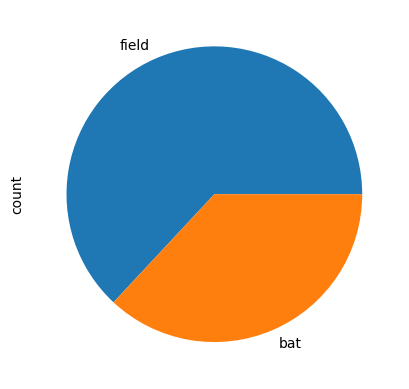

In [15]:
# after toss decision plot
after_toss = ipl["TossDecision"].value_counts()
after_toss.plot(kind="pie")


In [21]:
# how many matches has each team played
ipl.head(3)
(ipl["Team1"].value_counts() + ipl['Team2'].value_counts()).sort_values(ascending = True)

,count
Kochi Tuskers Kerala,14
Rising Pune Supergiants,14
Lucknow Super Giants,15
Gujarat Titans,16
Rising Pune Supergiant,16
Punjab Kings,28
Gujarat Lions,30
Pune Warriors,46
Delhi Capitals,63
Deccan Chargers,75


In [22]:
movies = pd.read_csv('movies.csv')
movies.head(1)

,title_x,imdb_id,poster_path,wiki_link,title_y,original_title,is_adult,year_of_release,runtime,genres,imdb_rating,imdb_votes,story,summary,tagline,actors,wins_nominations,release_date
0,Uri: The Surgical Strike,tt8291224,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Uri:_The_Surgica...,Uri: The Surgical Strike,Uri: The Surgical Strike,0,2019,138,Action|Drama|War,8.4,35112,Divided over five chapters the film chronicle...,Indian army special forces execute a covert op...,NaN,Vicky Kaushal|Paresh Rawal|Mohit Raina|Yami Ga...,4 wins,11 January 2019 (USA)


In [26]:
# sort_values (series and dataframe)
# sorts the series and

movies['title_x'].sort_values()   # just returns the sorted values

movies.sort_values('title_x')     # sorts and returns whole table according to a single column
movies.sort_values('title_x',ascending=False)     # sorts and returns whole table according to a single column



,title_x,imdb_id,poster_path,wiki_link,title_y,original_title,is_adult,year_of_release,runtime,genres,imdb_rating,imdb_votes,story,summary,tagline,actors,wins_nominations,release_date
1623,Zubeidaa,tt0255713,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Zubeidaa,Zubeidaa,Zubeidaa,0,2001,153,Biography|Drama|History,6.2,1384,The film begins with Riyaz (Rajat Kapoor) Zub...,Zubeidaa an aspiring Muslim actress marries ...,The Story of a Princess,Karisma Kapoor|Rekha|Manoj Bajpayee|Rajit Kapo...,3 wins & 13 nominations,19 January 2001 (India)
939,Zor Lagaa Ke...Haiya!,tt1479857,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Zor_Lagaa_Ke...H...,Zor Lagaa Ke... Haiya!,Zor Lagaa Ke... Haiya!,0,2009,\N,Comedy|Drama|Family,6.4,46,A tree narrates the story of four Mumbai-based...,Children build a tree-house to spy on a beggar...,NaN,Meghan Jadhav|Mithun Chakraborty|Riya Sen|Seem...,NaN,NaN
756,Zokkomon,tt1605790,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Zokkomon,Zokkomon,Zokkomon,0,2011,109,Action|Adventure,4.0,274,After the passing of his parents in an acciden...,An orphan is abused and abandoned believed to...,Betrayal. Friendship. Bravery.,Darsheel Safary|Anupam Kher|Manjari Fadnnis|Ti...,NaN,22 April 2011 (India)
670,Zindagi Tere Naam,tt2164702,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Zindagi_Tere_Naam,Zindagi Tere Naam,Zindagi Tere Naam,0,2012,120,Romance,4.7,27,Mr. Singh an elderly gentleman relates to hi...,Mr. Singh an elderly gentleman relates to hi...,NaN,Mithun Chakraborty|Ranjeeta Kaur|Priyanka Meht...,1 win,16 March 2012 (India)
778,Zindagi Na Milegi Dobara,tt1562872,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Zindagi_Na_Mileg...,Zindagi Na Milegi Dobara,Zindagi Na Milegi Dobara,0,2011,155,Comedy|Drama,8.1,60826,Three friends decide to turn their fantasy vac...,Three friends decide to turn their fantasy vac...,NaN,Hrithik Roshan|Farhan Akhtar|Abhay Deol|Katrin...,30 wins & 22 nominations,15 July 2011 (India)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1039,1971 (2007 film),tt0983990,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/1971_(2007_film),1971,1971,0,2007,160,Action|Drama|War,7.9,1121,Based on true facts the film revolves around ...,Based on true facts the film revolves around ...,Honor the heroes.......,Manoj Bajpayee|Ravi Kishan|Deepak Dobriyal|,1 win,9 March 2007 (India)
723,1920: The Evil Returns,tt2222550,https://upload.wikimedia.org/wikipedia/en/e/e7...,https://en.wikipedia.org/wiki/1920:_The_Evil_R...,1920: Evil Returns,1920: Evil Returns,0,2012,124,Drama|Horror|Romance,4.8,1587,This story revolves around a famous poet who m...,This story revolves around a famous poet who m...,Possession is back,Vicky Ahuja|Tia Bajpai|Irma Jämhammar|Sharad K...,NaN,2 November 2012 (India)
287,1920: London,tt5638500,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/1920_London,1920 London,1920 London,0,2016,120,Horror|Mystery,4.1,1373,Shivangi (Meera Chopra) lives in London with h...,After her husband is possessed by an evil spir...,Fear strikes again,Sharman Joshi|Meera Chopra|Vishal Karwal|Suren...,NaN,6 May 2016 (USA)
1021,1920 (film),tt1301698,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/1920_(film),1920,1920,0,2008,138,Horror|Mystery|Romance,6.4,2588,A devotee of Bhagwan Shri Hanuman Arjun Singh...,After forsaking his family and religion a hus...,A Love Made in Heaven...A Revenge Born in Hell...,Rajniesh Duggall|Adah Sharma|Anjori Alagh|Raj ...,NaN,12 September 2008 (India)


In [27]:
# what happens if we apply sort on a datsframe with missing values
students.sort_values("name")   #stores the nan values at the last of the program.

NameError: name 'students' is not defined

In [28]:
students.sort_values('name',na_position='first',ascending = Flase)

NameError: name 'students' is not defined